# 06 — Service Layer: activity plan suggestions

Ties everything together: `find_pois` (category/amenity/district matching,
from KG Modelling) + `GtfsRouter` (travel time, from the Reasoning Layer)
into `service/activity_planner.py`'s `plan_activities()` — which generates
actual multi-stop **itineraries**, not just ranked POI lists or bare
travel-time chains. Matches the one-pager's motivation directly ("someone
else planned a day... for you").

Each POI category has a **default visit duration** (`DEFAULT_VISIT_MINUTES`)
— rough, stated assumptions, not derived from any data source — that count
toward the time budget alongside travel, and that can be overridden per
query. This is what turns "here's a chain of transport links" into "here's an
actual afternoon plan."

Two filters can be applied per interest: **category** (which POI class,
already required) and **district** (restrict that stop to one of Vienna's
23 districts). Every result also carries a best-effort **description**
composed from whatever structured fields the KG actually has for that POI
(address, amenities, opening hours, ...) — there's no free-text description
field in the source data, so this is assembled, not looked up.

Plans can now be **1 to 5 stops**, not just 2 — built via a bounded **beam
search** rather than exhaustive branching (see Section 7 and
`service/activity_planner.py`'s module docstring for why exhaustive search
isn't tractable past ~2 stops). Two scope decisions worth knowing before
using it: stops are visited in **exactly the order you list interests**
(no automatic reordering to find a faster route — a deliberate choice, not
an oversight, see Section 7), and the same POI is **never suggested twice**
within one plan.

Scope, stated plainly (see `service/activity_planner.py`'s docstring):
- Plans are 1 to 5 stops (origin → stop1 → ... → stopN), in the given order.
- `time_budget_min` covers travel + every visit, but **not** a return trip
  home — the plan ends when you're done at the last stop. It also does not
  auto-scale with stop count: an infeasible budget for N stops just returns
  zero plans.

Two ways to use this notebook: fixed, reproducible example queries
(Sections 1-7) and a live interactive widget (Section 9) — the widget cell
won't show meaningful output when run headlessly via `nbconvert`/export, it
needs an actual running Jupyter kernel with a click.

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

from rdflib import Graph
from reasoning.gtfs_routing import GtfsRouter
from reasoning.preference_filter import list_districts
from service.activity_planner import plan_activities, format_plan, DEFAULT_VISIT_MINUTES
import matplotlib.pyplot as plt

g = Graph()
g.parse("../kg/vienna_mobility_kg.ttl", format="turtle")
router = GtfsRouter(date="20260815")
print(f"KG: {len(g)} triples, GTFS router ready")

# a few well-connected, recognizable named origins -- avoids ever having to
# type raw lon/lat (which is exactly how an earlier session found a real bug:
# (lon, lat) typed in the wrong order looks like valid coordinates but
# silently points somewhere off the map)
LANDMARKS = {
    "Karlsplatz": (16.368948, 48.200955),
    "Stephansplatz": (16.372931, 48.208611),
    "Praterstern": (16.393889, 48.216111),
    "Schwedenplatz": (16.377500, 48.212222),
    "Westbahnhof": (16.337778, 48.196389),
}

KG: 80485 triples, GTFS router ready


## Default visit durations per category

In [2]:
for cls, minutes in DEFAULT_VISIT_MINUTES.items():
    print(f"  {cls:20} {minutes} min")

  Museum               90 min
  Library              30 min
  BathingSite          90 min
  Park                 45 min
  SwimmingPool         90 min
  PlaygroundArea       45 min
  TouristAttraction    30 min


## 1. Single-stop itinerary: a dog-friendly park, 60-minute budget

Budget now covers travel *and* the visit, not just travel — a park with a
2.9-minute commute and the default 45-minute visit uses 48 of the 60 minutes.
Each result now also prints a description line (composed from whatever the
KG has for that POI: amenities, address, etc.).

In [3]:
origin_lon, origin_lat = LANDMARKS["Karlsplatz"]

plans = plan_activities(g, router, origin_lon, origin_lat,
                         interests=[{"label": "a dog-friendly park", "poi_classes": ["Park"],
                                     "required_amenities": ["Dogs allowed"]}],
                         time_budget_min=60, depart_after="14:00:00")
print(f"{len(plans)} option(s):\n")
for p in plans[:3]:
    print(format_plan(p, "14:00:00"))
    print()

4 option(s):

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
Done at 14:47 -- 2.9 min travel + 45 min visiting = 48 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: Modenapark (arrive 14:06, 6.6 min travel, 0 transfers; visit until 14:51, 45 min)
     in 3. Landstraße -- 7,776 m² -- amenities: Dogs allowed, Playground, Water feature
Done at 14:51 -- 6.6 min travel + 45 min visiting = 52 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: GA Linke Bahngasse (arrive 14:07, 7.3 min travel, 0 transfers; visit until 14:52, 45 min)
     in 3. Landstraße -- 2,625 m² -- amenities: Dogs allowed
Done at 14:52 -- 7.3 min travel + 45 min visiting = 52 min total (no return trip included)



## 2. A real 2-stop itinerary: dog-friendly park, then a library

Default visit times (45 + 30 min) plus travel, all within one budget.

In [4]:
plans2 = plan_activities(g, router, origin_lon, origin_lat,
                          interests=[
                              {"label": "a dog-friendly park", "poi_classes": ["Park"], "required_amenities": ["Dogs allowed"]},
                              {"label": "a library", "poi_classes": ["Library"]},
                          ],
                          time_budget_min=120, depart_after="14:00:00")
print(f"{len(plans2)} plan(s):\n")
for p in plans2[:3]:
    print(format_plan(p, "14:00:00"))
    print()

best_plan = plans2[0]

4 plan(s):

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
  -> a library: Bücherei Wieden (arrive 14:54, 6.8 min travel, 0 transfers; visit until 15:24, 30 min)
     in 4. Wieden -- at 4., Favoritenstraße 8 -- open Mo 11.00 bis 18.00 Uhr; Di 11.00 bis 18.00 Uhr; Mi 11.00 bis 18.00 Uhr; Do 11.00 bis 18.00 Uhr; Fr 11.00 bis 18.00 Uhr -- tel 01 4000-04 161 -- email wieden@buechereien.wien.at -- https://buechereien.wien.gv.at/B%C3%BCchereien-Wien/Standorte-%C3%96ffnungszeiten/Zweigstellen/B%C3%BCcherei-Wieden
Done at 15:24 -- 9.7 min travel + 75 min visiting = 85 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
  -> a library: Büc

## 3. Same itinerary, but with overridden visit times

Say you only want a quick 15-minute stop at the park (versus the 45-minute
default) and a longer 45-minute library visit (versus 30) — pass
`visit_minutes` per interest.

In [5]:
plans3 = plan_activities(g, router, origin_lon, origin_lat,
                          interests=[
                              {"label": "a dog-friendly park", "poi_classes": ["Park"],
                               "required_amenities": ["Dogs allowed"], "visit_minutes": 15},
                              {"label": "a library", "poi_classes": ["Library"], "visit_minutes": 45},
                          ],
                          time_budget_min=90, depart_after="14:00:00")
print(f"{len(plans3)} plan(s) with custom visit times:\n")
for p in plans3[:2]:
    print(format_plan(p, "14:00:00"))
    print()

4 plan(s) with custom visit times:

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:17, 15 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
  -> a library: Bücherei Wieden (arrive 14:24, 6.8 min travel, 0 transfers; visit until 15:09, 45 min)
     in 4. Wieden -- at 4., Favoritenstraße 8 -- open Mo 11.00 bis 18.00 Uhr; Di 11.00 bis 18.00 Uhr; Mi 11.00 bis 18.00 Uhr; Do 11.00 bis 18.00 Uhr; Fr 11.00 bis 18.00 Uhr -- tel 01 4000-04 161 -- email wieden@buechereien.wien.at -- https://buechereien.wien.gv.at/B%C3%BCchereien-Wien/Standorte-%C3%96ffnungszeiten/Zweigstellen/B%C3%BCcherei-Wieden
Done at 15:09 -- 9.7 min travel + 60 min visiting = 70 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:17, 15 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water fea

## 4. Setting a maximum walking time

For someone running around with a stroller (or any other reason a 15+ minute
walk to a stop isn't realistic), `max_walk_min` caps how far the plan is
allowed to walk at *every* leg — set once, applied consistently, not
something to remember to add per call. Unlike the time budget, this is a
**hard constraint**: if nothing is walkable within the limit, that leg is
skipped rather than silently walking farther than asked.

In [6]:
park_library_interests = [
    {"label": "a dog-friendly park", "poi_classes": ["Park"], "required_amenities": ["Dogs allowed"]},
    {"label": "a library", "poi_classes": ["Library"]},
]

plans_10min = plan_activities(g, router, origin_lon, origin_lat,
                               interests=park_library_interests,
                               time_budget_min=120, depart_after="14:00:00", max_walk_min=10)
print(f"{len(plans_10min)} plan(s) with a 10-minute walk cap:\n")
for p in plans_10min[:2]:
    print(format_plan(p, "14:00:00"))
    print()

plans_5min = plan_activities(g, router, origin_lon, origin_lat,
                              interests=park_library_interests,
                              time_budget_min=120, depart_after="14:00:00", max_walk_min=5)
print(f"{len(plans_5min)} plan(s) with a 5-minute walk cap:\n")
for p in plans_5min[:2]:
    print(format_plan(p, "14:00:00"))
    print()

# an unreasonably tight cap should degrade gracefully, not error
plans_tight = plan_activities(g, router, origin_lon, origin_lat,
                               interests=[{"label": "a museum", "poi_classes": ["Museum"]}],
                               time_budget_min=60, depart_after="14:00:00", max_walk_min=1)
print(f"With an unreasonably tight 1-minute cap: {len(plans_tight)} plan(s) found "
      "(expected to be few or none -- confirms the limit is a real constraint, not decorative)")

4 plan(s) with a 10-minute walk cap:

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
  -> a library: Bücherei Wieden (arrive 14:54, 6.8 min travel, 0 transfers; visit until 15:24, 30 min)
     in 4. Wieden -- at 4., Favoritenstraße 8 -- open Mo 11.00 bis 18.00 Uhr; Di 11.00 bis 18.00 Uhr; Mi 11.00 bis 18.00 Uhr; Do 11.00 bis 18.00 Uhr; Fr 11.00 bis 18.00 Uhr -- tel 01 4000-04 161 -- email wieden@buechereien.wien.at -- https://buechereien.wien.gv.at/B%C3%BCchereien-Wien/Standorte-%C3%96ffnungszeiten/Zweigstellen/B%C3%BCcherei-Wieden
Done at 15:24 -- 9.7 min travel + 75 min visiting = 85 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water f

4 plan(s) with a 5-minute walk cap:

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
  -> a library: Bücherei Wieden (arrive 14:54, 6.8 min travel, 0 transfers; visit until 15:24, 30 min)
     in 4. Wieden -- at 4., Favoritenstraße 8 -- open Mo 11.00 bis 18.00 Uhr; Di 11.00 bis 18.00 Uhr; Mi 11.00 bis 18.00 Uhr; Do 11.00 bis 18.00 Uhr; Fr 11.00 bis 18.00 Uhr -- tel 01 4000-04 161 -- email wieden@buechereien.wien.at -- https://buechereien.wien.gv.at/B%C3%BCchereien-Wien/Standorte-%C3%96ffnungszeiten/Zweigstellen/B%C3%BCcherei-Wieden
Done at 15:24 -- 9.7 min travel + 75 min visiting = 85 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water fe

## 5. Examples that actually need a transfer

Every example so far happened to resolve with 0 transfers — Karlsplatz is a
major interchange, so most nearby POIs are directly reachable from there.
Swimming pools are a good category to force the point: Vienna's public pools
are spread out toward the city edges, away from the density near Karlsplatz,
so several genuinely need 1 or 2 transfers. Found via
`find_pois(..., poi_classes=["SwimmingPool"])` and checking `num_transfers`
on the results.

In [7]:
q = """
PREFIX schema: <https://schema.org/>
PREFIX viennakg: <http://example.org/viennakg#>
PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
SELECT ?lon ?lat WHERE { ?p a viennakg:SwimmingPool ; schema:name "Hietzinger Bad" ; geo:long ?lon ; geo:lat ?lat . }
"""
h_lon, h_lat = [(float(r.lon), float(r.lat)) for r in g.query(q)][0]

result_1t = router.estimate_travel_time(origin_lon, origin_lat, h_lon, h_lat, depart_after="14:00:00")
print(f"Karlsplatz -> Hietzinger Bad: {result_1t['num_transfers']} transfer(s), {result_1t['total_travel_str']}")
for leg in result_1t["legs"]:
    print(f"  leg: line {leg['line']}, {leg['board_stop_name']} -> {leg['alight_stop_name']}")

q2 = """
PREFIX schema: <https://schema.org/>
PREFIX viennakg: <http://example.org/viennakg#>
PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
SELECT ?lon ?lat WHERE { ?p a viennakg:SwimmingPool ; schema:name "Höpflerbad" ; geo:long ?lon ; geo:lat ?lat . }
"""
p_lon, p_lat = [(float(r.lon), float(r.lat)) for r in g.query(q2)][0]

result_2t = router.estimate_travel_time(origin_lon, origin_lat, p_lon, p_lat, depart_after="14:00:00")
print(f"\nKarlsplatz -> Höpflerbad: {result_2t['num_transfers']} transfer(s), {result_2t['total_travel_str']}")
for leg in result_2t["legs"]:
    print(f"  leg: line {leg['line']}, {leg['board_stop_name']} -> {leg['alight_stop_name']}")

Karlsplatz -> Hietzinger Bad: 1 transfer(s), 43 min
  leg: line 1, Karlsplatz -> Matzleinsdorfer Platz
  leg: line 62, Matzleinsdorfer Platz -> Atzgersdorfer Straße



Karlsplatz -> Höpflerbad: 2 transfer(s), 1h 3min
  leg: line 1, Karlsplatz -> Matzleinsdorfer Platz
  leg: line 62, Matzleinsdorfer Platz -> Sonnergasse
  leg: line 62A, Sonnergasse -> Brunner Straße/Erlaaer Straße


And the same thing through `plan_activities()`, so a full itinerary can
include a multi-transfer leg, not just the single-hop `estimate_travel_time()`
calls above.

In [8]:
swim_plans = plan_activities(g, router, origin_lon, origin_lat,
                              interests=[{"label": "a swim", "poi_classes": ["SwimmingPool"]}],
                              time_budget_min=150, depart_after="14:00:00", top_plans=40)

# plan_activities ranks fastest-first, and Karlsplatz has a 0-transfer pool
# option -- pick out one that actually needed a transfer, to keep this
# section's point concrete rather than showing the same 0-transfer result again
transfer_plans = [p for p in swim_plans if p["stops"][0]["num_transfers"] > 0]
print(f"{len(transfer_plans)} of {len(swim_plans)} ranked options needed at least one transfer\n")
if transfer_plans:
    print(format_plan(transfer_plans[0], "14:00:00"))
    print(f"\n(needed {transfer_plans[0]['stops'][0]['num_transfers']} transfer(s))")

0 of 4 ranked options needed at least one transfer



## 6. District filter

Every POI already links to its district via `schema:containedInPlace` (from
KG Modelling), so filtering "a park, but specifically in the 6th district"
needed no new data — just exposing it as a `district` parameter. Accepts a
district number (1-23), `"BezirkN"`, or a substring of the district label
(e.g. `"mariahilf"`). Applied *per interest*, not plan-wide: a 2-stop plan
can legitimately want stop 1 in one district and stop 2 anywhere (or a
different district) — that's why `district` lives inside each interest dict
rather than as one argument to `plan_activities()`.

In [9]:
print("All 23 districts:")
for d in list_districts(g):
    print(f"  {d['number']:>2}  {d['label']}")

All 23 districts:
   1  1. Innere Stadt
   2  2. Leopoldstadt
   3  3. Landstraße
   4  4. Wieden
   5  5. Margareten
   6  6. Mariahilf
   7  7. Neubau
   8  8. Josefstadt
   9  9. Alsergrund
  10  10. Favoriten
  11  11. Simmering
  12  12. Meidling
  13  13. Hietzing
  14  14. Penzing
  15  15. Rudolfsheim-Fünfhaus
  16  16. Ottakring
  17  17. Hernals
  18  18. Währing
  19  19. Döbling
  20  20. Brigittenau
  21  21. Floridsdorf
  22  22. Donaustadt
  23  23. Liesing


In [10]:
# Without a district filter: nearest dog-friendly parks to Karlsplatz overall
plans_any = plan_activities(g, router, origin_lon, origin_lat,
                             interests=[{"label": "a dog-friendly park", "poi_classes": ["Park"],
                                         "required_amenities": ["Dogs allowed"]}],
                             time_budget_min=90, depart_after="14:00:00", top_plans=3)
print("No district filter -- nearest dog-friendly parks:\n")
for p in plans_any:
    print(format_plan(p, "14:00:00"))
    print()

# Restricted to the 6th district (Mariahilf) specifically
plans_d6 = plan_activities(g, router, origin_lon, origin_lat,
                            interests=[{"label": "a dog-friendly park", "poi_classes": ["Park"],
                                        "required_amenities": ["Dogs allowed"], "district": 6}],
                            time_budget_min=90, depart_after="14:00:00", top_plans=3)
print("district=6 (Mariahilf) only:\n")
for p in plans_d6:
    print(format_plan(p, "14:00:00"))
    print()

No district filter -- nearest dog-friendly parks:

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
Done at 14:47 -- 2.9 min travel + 45 min visiting = 48 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: Modenapark (arrive 14:06, 6.6 min travel, 0 transfers; visit until 14:51, 45 min)
     in 3. Landstraße -- 7,776 m² -- amenities: Dogs allowed, Playground, Water feature
Done at 14:51 -- 6.6 min travel + 45 min visiting = 52 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: GA Linke Bahngasse (arrive 14:07, 7.3 min travel, 0 transfers; visit until 14:52, 45 min)
     in 3. Landstraße -- 2,625 m² -- amenities: Dogs allowed
Done at 14:52 -- 7.3 min travel + 45 min visiting = 52 min total (no return trip included)



district=6 (Mariahilf) only:

Depart at 14:00:00
  -> a dog-friendly park: Gumpendorfer Gürtel Hundezone (arrive 14:12, 12.2 min travel, 0 transfers; visit until 14:57, 45 min)
     in 6. Mariahilf -- 187 m² -- amenities: Dogs allowed, Water feature
Done at 14:57 -- 12.2 min travel + 45 min visiting = 57 min total (no return trip included)

Depart at 14:00:00
  -> a dog-friendly park: Franz-Schwarz-Park (arrive 14:12, 12.3 min travel, 0 transfers; visit until 14:57, 45 min)
     in 6. Mariahilf -- 875 m² -- amenities: Dogs allowed, Water feature
Done at 14:57 -- 12.3 min travel + 45 min visiting = 57 min total (no return trip included)



In [11]:
# District filters combine across stops -- a 2-stop plan that pins stop 1 to
# one district and leaves stop 2 unrestricted (it can land in any district,
# including a different one than stop 1)
plans_mixed = plan_activities(g, router, origin_lon, origin_lat,
                               interests=[
                                   {"label": "a dog-friendly park", "poi_classes": ["Park"],
                                    "required_amenities": ["Dogs allowed"], "district": 6},
                                   {"label": "a museum", "poi_classes": ["Museum"]},
                               ],
                               time_budget_min=240, depart_after="14:00:00")
print(f"{len(plans_mixed)} plan(s), stop 1 pinned to district 6, stop 2 unrestricted:\n")
if plans_mixed:
    print(format_plan(plans_mixed[0], "14:00:00"))
    stop1_district = plans_mixed[0]["stops"][0]["description"].split(" -- ")[0]
    stop2_district = plans_mixed[0]["stops"][1]["description"].split(" -- ")[0]
    note = ("a different district than" if stop1_district != stop2_district
            else "the same district as (nearest museum happened to be there too)")
    print(f"\n(stop 1 landed {stop1_district}; stop 2 landed {stop2_district} -- {note} stop 1)")

4 plan(s), stop 1 pinned to district 6, stop 2 unrestricted:

Depart at 14:00:00
  -> a dog-friendly park: Gumpendorfer Gürtel Hundezone (arrive 14:12, 12.2 min travel, 0 transfers; visit until 14:57, 45 min)
     in 6. Mariahilf -- 187 m² -- amenities: Dogs allowed, Water feature
  -> a museum: Sanitärhistorisches Museum (arrive 15:00, 3.7 min travel, 0 transfers; visit until 16:30, 90 min)
     in 6. Mariahilf -- at 06., Mollardgasse 87 -- https://www.wien.gv.at/ma53/museen/san-his.htm
Done at 16:30 -- 15.9 min travel + 135 min visiting = 151 min total (no return trip included)

(stop 1 landed in 6. Mariahilf; stop 2 landed in 6. Mariahilf -- the same district as (nearest museum happened to be there too) stop 1)


## 7. Up to 5 stops, via beam search

`plan_activities()` now accepts 1 to 5 interests. More than 2 stops can't
be found by trying every candidate at every stage -- that's `O(candidates^N)`
network searches (minutes of runtime for 5 stops). Instead it uses a
**beam search**: after each stop, only the `beam_width` best partial
itineraries (by time so far) are kept and expanded further; the rest are
dropped. This bounds the cost to roughly `beam_width x N` network searches
instead of exponential growth -- see `service/activity_planner.py`'s module
docstring ("Why beam search") for the full reasoning.

Two consequences worth seeing directly, not just stating:
- **It's a heuristic, not exhaustive** -- a narrower beam is faster but can
  miss a better itinerary that a wider beam would find.
- **Stop order is exactly what you specify.** The search does not try
  reordering your interests to find a faster route (a deliberate scope
  decision, confirmed before building this -- searching orderings too would
  multiply cost further, up to 5! = 120x, for a benefit that's often small
  in a dense city like Vienna).

In [12]:
five_stop_interests = [
    {"label": "a dog-friendly park", "poi_classes": ["Park"], "required_amenities": ["Dogs allowed"]},
    {"label": "a library", "poi_classes": ["Library"]},
    {"label": "a museum", "poi_classes": ["Museum"]},
    {"label": "a playground", "poi_classes": ["PlaygroundArea"]},
    {"label": "a tourist attraction", "poi_classes": ["TouristAttraction"]},
]

import time
t0 = time.time()
plans5 = plan_activities(g, router, origin_lon, origin_lat, interests=five_stop_interests,
                          time_budget_min=600, depart_after="14:00:00")
print(f"{len(plans5)} plan(s) found in {time.time() - t0:.1f}s (beam_width={4}, the default)\n")
if plans5:
    print(format_plan(plans5[0], "14:00:00"))

4 plan(s) found in 38.1s (beam_width=4, the default)

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
  -> a library: Bücherei Wieden (arrive 14:54, 6.8 min travel, 0 transfers; visit until 15:24, 30 min)
     in 4. Wieden -- at 4., Favoritenstraße 8 -- open Mo 11.00 bis 18.00 Uhr; Di 11.00 bis 18.00 Uhr; Mi 11.00 bis 18.00 Uhr; Do 11.00 bis 18.00 Uhr; Fr 11.00 bis 18.00 Uhr -- tel 01 4000-04 161 -- email wieden@buechereien.wien.at -- https://buechereien.wien.gv.at/B%C3%BCchereien-Wien/Standorte-%C3%96ffnungszeiten/Zweigstellen/B%C3%BCcherei-Wieden
  -> a museum: Rauchfangkehrermuseum (arrive 15:29, 4.8 min travel, 0 transfers; visit until 16:59, 90 min)
     in 4. Wieden -- at 04., Klagbaumgasse 4 -- https://www.rauchfangkehrermuseum.at/
  -> a playground: Rubenspark (arrive 17:01, 1.9 min travel, 0 transfers; visit until 1

Narrowing the beam trades plan quality for speed -- useful for a
faster interactive experience. Same 5 interests, `beam_width=2`:

In [13]:
t0 = time.time()
plans5_narrow = plan_activities(g, router, origin_lon, origin_lat, interests=five_stop_interests,
                                 time_budget_min=600, depart_after="14:00:00", beam_width=2)
print(f"{len(plans5_narrow)} plan(s) found in {time.time() - t0:.1f}s (beam_width=2)\n")
if plans5_narrow:
    print(format_plan(plans5_narrow[0], "14:00:00"))
    same_best = plans5 and plans5_narrow[0]["total_itinerary_min"] == plans5[0]["total_itinerary_min"]
    print(f"\n(found {'the same' if same_best else 'a different, likely worse'} best plan as beam_width=4, "
          f"{'confirming the narrower beam was still wide enough here' if same_best else 'showing the quality/speed tradeoff in practice'})")

2 plan(s) found in 19.3s (beam_width=2)

Depart at 14:00:00
  -> a dog-friendly park: Resselpark (arrive 14:02, 2.9 min travel, 0 transfers; visit until 14:47, 45 min)
     in 4. Wieden -- 41,531 m² -- amenities: Dogs allowed, Playground, Water feature
  -> a library: Bücherei Wieden (arrive 14:54, 6.8 min travel, 0 transfers; visit until 15:24, 30 min)
     in 4. Wieden -- at 4., Favoritenstraße 8 -- open Mo 11.00 bis 18.00 Uhr; Di 11.00 bis 18.00 Uhr; Mi 11.00 bis 18.00 Uhr; Do 11.00 bis 18.00 Uhr; Fr 11.00 bis 18.00 Uhr -- tel 01 4000-04 161 -- email wieden@buechereien.wien.at -- https://buechereien.wien.gv.at/B%C3%BCchereien-Wien/Standorte-%C3%96ffnungszeiten/Zweigstellen/B%C3%BCcherei-Wieden
  -> a museum: Rauchfangkehrermuseum (arrive 15:29, 4.8 min travel, 0 transfers; visit until 16:59, 90 min)
     in 4. Wieden -- at 04., Klagbaumgasse 4 -- https://www.rauchfangkehrermuseum.at/
  -> a playground: Rubenspark (arrive 17:01, 1.9 min travel, 0 transfers; visit until 17:46, 45 min)

And confirming the **dedup guarantee** directly -- three "Park" interests
in a row, wide budget, no district/amenity restriction, so overlap would be
easy if it weren't explicitly prevented:

In [14]:
plans_dedup = plan_activities(g, router, origin_lon, origin_lat,
                               interests=[{"label": "park A", "poi_classes": ["Park"]},
                                          {"label": "park B", "poi_classes": ["Park"]},
                                          {"label": "park C", "poi_classes": ["Park"]}],
                               time_budget_min=300, depart_after="14:00:00")
if plans_dedup:
    names = [s["name"] for s in plans_dedup[0]["stops"]]
    print(f"Stops chosen: {names}")
    print(f"All different POIs: {len(names) == len(set(names))}")

Stops chosen: ['Girardipark', 'Esperantopark', 'PA Secession']
All different POIs: True


## 8. What the best default-visit-time plan looks like on the map

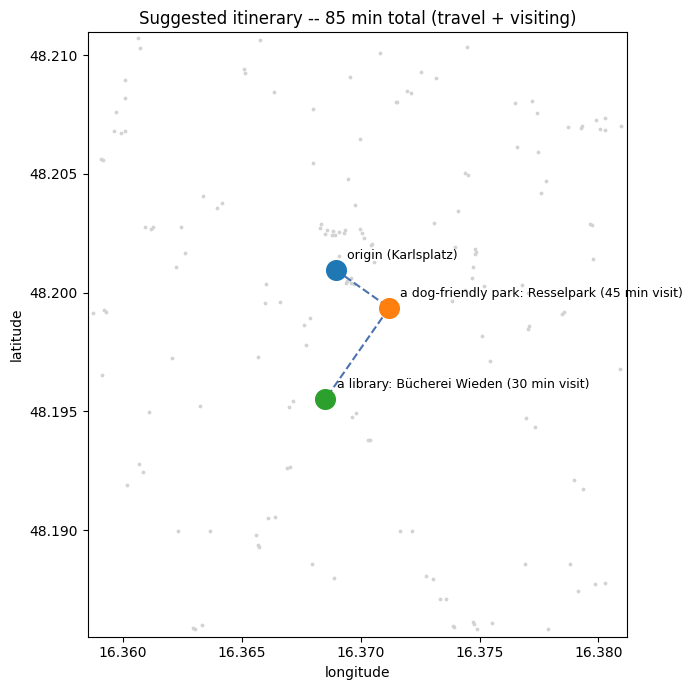

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

stop_lons = router.stops["stop_lon"].to_numpy()
stop_lats = router.stops["stop_lat"].to_numpy()
ax.scatter(stop_lons, stop_lats, s=3, color="lightgray", zorder=1)

points = [(origin_lon, origin_lat, "origin (Karlsplatz)")]
for stop in best_plan["stops"]:
    points.append((stop["lon"], stop["lat"], f"{stop['label']}: {stop['name']} ({stop['visit_min']:.0f} min visit)"))

xs, ys = zip(*[(p[0], p[1]) for p in points])
ax.plot(xs, ys, "--", color="#4C72B0", zorder=2)
for lon, lat, label in points:
    ax.scatter([lon], [lat], s=200, zorder=3)
    ax.annotate(label, (lon, lat), textcoords="offset points", xytext=(8, 8), fontsize=9)

pad = max(0.01, (max(xs) - min(xs)) * 0.6, (max(ys) - min(ys)) * 0.6)
ax.set_xlim(min(xs) - pad, max(xs) + pad)
ax.set_ylim(min(ys) - pad, max(ys) + pad)

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"Suggested itinerary -- {best_plan['total_itinerary_min']:.0f} min total (travel + visiting)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 9. Interactive: ask for your own itinerary

Pick a starting landmark and up to 5 interests, each with its own category
dropdown, an independent district dropdown ("Any district" leaves that stop
unrestricted), an optional required amenity, and a visit-time slider
(pre-filled with that category's default -- adjust if you want). Interest 1
is required; leave any interest from 2 onward as "(none)" to stop the plan
there -- **interests must be filled in order** (e.g. picking interest 3
while interest 2 is still "(none)" just gets treated as a 1-stop plan;
there's no gap-filling). Also set a max-walk-time slider (applied to every
leg), a `beam_width` slider (search breadth -- higher finds better plans but
is slower, see Section 7), and a total time budget. Each result shows a
best-effort description line per stop, straight from the KG.

**Needs a live kernel to actually use** — running this notebook via
`nbconvert --execute` (or any headless export) renders the widgets but can't
simulate a button click, so this cell alone won't show a result outside a
real Jupyter session. Sections 1-7 above already demonstrate the exact same
underlying calls, so the logic is validated either way. Note plans with 4-5
stops and a wide beam can take tens of seconds to compute (see Section 7's
timings) -- the widget will look unresponsive while that runs, not broken.

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output

POI_OPTIONS = ["Museum", "Library", "BathingSite", "Park", "SwimmingPool", "PlaygroundArea", "TouristAttraction"]
DISTRICT_OPTIONS = [("Any district", None)] + [(f"{d['number']}. {d['label'].split('. ', 1)[-1]}", d["number"])
                                                 for d in list_districts(g)]
NONE_OPTION = "(none)"

origin_dd = widgets.Dropdown(options=list(LANDMARKS.keys()), description="Start at:")

interest_rows = []
for i in range(1, 6):
    options = POI_OPTIONS if i == 1 else [NONE_OPTION] + POI_OPTIONS
    default_value = "Park" if i == 1 else NONE_OPTION
    interest_dd = widgets.Dropdown(options=options, value=default_value, description=f"Interest {i}:")
    district_dd = widgets.Dropdown(options=DISTRICT_OPTIONS, value=None, description=f"District {i}:")
    amenity_txt = widgets.Text(description=f"Amenity {i}:", placeholder="optional")
    visit_slider = widgets.IntSlider(value=DEFAULT_VISIT_MINUTES.get(default_value, 45), min=5, max=180, step=5,
                                      description=f"Visit {i} (min):")

    def _make_sync(slider):
        def _sync(change):
            if change["new"] != NONE_OPTION:
                slider.value = DEFAULT_VISIT_MINUTES.get(change["new"], 45)
        return _sync
    interest_dd.observe(_make_sync(visit_slider), names="value")

    interest_rows.append({"interest": interest_dd, "district": district_dd,
                           "amenity": amenity_txt, "visit": visit_slider})

budget_slider = widgets.IntSlider(value=150, min=20, max=600, step=10, description="Budget (min):")
max_walk_slider = widgets.IntSlider(value=15, min=2, max=30, step=1, description="Max walk (min):")
beam_width_slider = widgets.IntSlider(value=4, min=1, max=8, step=1, description="Beam width:")
depart_txt = widgets.Text(value="14:00:00", description="Depart after:")
go_button = widgets.Button(description="Find a plan", button_style="primary")
output = widgets.Output()

def on_click(_):
    with output:
        clear_output()
        lon, lat = LANDMARKS[origin_dd.value]
        interests = []
        for row in interest_rows:
            if row["interest"].value == NONE_OPTION:
                break  # stop at the first "(none)" -- no gap-filling, see markdown above
            interests.append({"label": row["interest"].value, "poi_classes": [row["interest"].value],
                               "required_amenities": [row["amenity"].value] if row["amenity"].value else None,
                               "district": row["district"].value,
                               "visit_minutes": row["visit"].value})
        plans = plan_activities(g, router, lon, lat, interests=interests,
                                 time_budget_min=budget_slider.value, depart_after=depart_txt.value,
                                 max_walk_min=max_walk_slider.value, beam_width=beam_width_slider.value)
        if not plans:
            print("No plan found within that budget/district combination -- try a larger budget, "
                  "a different district, a wider beam_width, or a different combination.")
        for p in plans[:3]:
            print(format_plan(p, depart_txt.value))
            print()

go_button.on_click(on_click)

rows_ui = [origin_dd]
for row in interest_rows:
    rows_ui += [row["interest"], row["district"], row["amenity"], row["visit"]]
rows_ui += [budget_slider, max_walk_slider, beam_width_slider, depart_txt, go_button, output]

display(widgets.VBox(rows_ui))

## Findings

**A hard walking-distance cap makes this usable for real mobility
constraints**, not just a nice-to-have — someone with a stroller (or any
other reason a long walk isn't realistic) can set `max_walk_min` once and
have it enforced strictly at every leg, rather than silently getting routed
through a 20-minute walk because "closest stop" happened to be far. Unlike
the time budget (a soft optimization target), this is a hard filter: legs
with nothing walkable in range are dropped, not approximated.

**Visit time turns a route chain into a plan.** Without it, "budget" only
meant "how much time can I spend on buses/trains," which isn't how anyone
actually thinks about planning an afternoon. Folding visit time into the
budget — and critically, into the *chaining* (leg 2 departs after leg 1's
visit ends, not right after arrival) — is what makes the output a genuine
itinerary with real clock times, not a routing artifact.

**The defaults are honest guesses, not data.** `DEFAULT_VISIT_MINUTES` has no
empirical backing — it's what seemed reasonable per category. Making them
overridable per query (rather than hardcoding them) means the tool is honest
about that uncertainty instead of presenting a guess as a fact.

**District filtering needed zero new ingestion** — `schema:containedInPlace`
was already on every POI from KG Modelling, so this was purely a query/API
surface change. The interesting design decision was making it per-interest
rather than plan-wide, since a 2-stop plan spanning two districts is a
completely normal, useful thing to ask for (Section 6 demonstrates exactly
that).

**There's no free-text description anywhere in the source data** — a real
gap worth naming rather than working around silently. `describe_poi()`
composes a best-effort summary from whatever structured fields exist
(address, amenities, opening hours, contact info, tourist-attraction
subcategory), which is useful but noticeably thinner for POI classes with
fewer source fields (e.g. `BathingSite`, which has almost none) — the
description is honest about "what the KG happens to know," not a
substitute for real editorial content.

**Still no return trip modelled.** A plan's "total time" ends when you leave
the last stop, not when you get home. Adding that back is a small, mechanical
extension (one more `travel_time_to()` call from the last stop back to
origin) — not done here to keep the scope of this pass focused, but worth
flagging as the obvious next increment rather than a hidden gap.

**Beam search made 5 stops tractable, at the cost of being a heuristic, not
an optimal search.** Naive branching (every candidate at every stage) is
exponential in stop count; a bounded beam keeps cost roughly linear in
`beam_width x stops` instead — the same "bounded, not exhaustive" trade the
2-transfer GTFS routing search already made. `beam_width` is a real
speed/quality knob, not a technicality: Section 7 shows the same 5-interest
query finding an equally good plan at `beam_width=2` in this case, but
that's not guaranteed in general — a narrower beam can genuinely miss a
better itinerary, it just happened not to here.

**Fixed stop order was a deliberate scope call, confirmed before
building.** The planner does not search alternate orderings of your chosen
interests to find a faster route — that would be a small traveling-salesman
problem layered on top of the beam search, multiplying cost further for a
benefit that's often small in a dense, well-connected city like Vienna.
Worth remembering if a plan looks suboptimal: reordering the `interests`
list yourself is the intended way to explore that, not something the tool
does automatically.